In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('../artifacts/Final_dataset_to_ML2.csv')

## Feature Engineering

In [3]:
# MPU magnitude
data['mpu1_acc_mag'] = np.sqrt(data['mpu1_acc_x']**2 + data['mpu1_acc_y']**2 + data['mpu1_acc_z']**2)
data['mpu2_acc_mag'] = np.sqrt(data['mpu2_acc_x']**2 + data['mpu2_acc_y']**2 + data['mpu2_acc_z']**2)

# FSR combined features
fsr_cols = ['fsr_1','fsr_2','fsr_3','fsr_4','fsr_5','fsr_6','fsr_7','fsr_8','fsr_9','fsr_10','fsr_11','fsr_12']
data['fsr_sum'] = data[fsr_cols].sum(axis=1)
data['fsr_std'] = data[fsr_cols].std(axis=1)

# BPM + Temperature combined magnitude
data['bpm_feature'] = np.sqrt(data['bpm_avg']**2 + data['bpm_diff']**2)
data['temp_feature'] = np.sqrt(data['temp_avg']**2 + data['temp_diff']**2)

# Interaction feature
data['bpm_psycho_interaction'] = data['bpm_avg'] * data['PSYCOLOGICAL_SCORE']



In [4]:
data.head()

,temp1,temp2,bpm1,bpm2,spo2_1,spo2_2,mpu1_acc_x,mpu1_acc_y,mpu1_acc_z,mpu2_acc_x,...,Occupation_8,Occupation_9,Occupation_10,Occupation_11,Occupation_12,Occupation_13,Occupation_14,Occupation_15,bpm_feature,temp_feature
0,-0.090943,0.354028,1.676295,1.492223,0.492972,-0.507866,-1.450207,0.109063,-1.441127,0.893865,...,False,False,False,False,False,False,False,False,108.541467,36.570924
1,0.533556,-0.530694,-1.297393,1.288076,0.492972,1.497397,-0.973867,-0.930065,-1.047061,0.724407,...,False,False,False,False,False,False,False,False,93.107465,36.500098
2,0.238654,0.839757,-0.824306,-1.093646,-0.508461,1.497397,0.799609,1.162912,-0.011229,-1.088358,...,False,False,False,False,False,False,False,False,71.112587,36.806664
3,-1.149123,-1.432764,-0.080884,0.131240,0.492972,-0.006551,0.128048,-0.467653,1.345918,-1.020575,...,False,False,False,False,False,False,False,False,85.552615,35.750358
4,1.158056,0.249943,0.459786,0.879781,-1.009177,-0.507866,-0.255453,0.787960,-1.467109,0.174320,...,False,False,False,False,False,False,False,False,95.189285,36.903664


## Feature Selection

In [5]:
sensor_features = ['mpu1_acc_mag','mpu2_acc_mag','fsr_sum','fsr_std','bpm_feature','temp_feature']
other_features = ['BMI','Age','PSYCOLOGICAL_SCORE','LIFESTYLE_SCORE','SOCIAL_SCORE','posture_level']

all_features = sensor_features + other_features
X = data[all_features]
y = data['stress_level']


##  Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

## Handle Imbalanced Classes (SMOTE)

In [8]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

## Random Forest Model

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# Train
model.fit(X_res, y_res)

# Predict
y_pred = model.predict(X_test)


##  Evaluation

In [10]:
print("Train Accuracy:", model.score(X_res, y_res))
print("Test Accuracy:", model.score(X_test, y_test))
print(classification_report(y_test, y_pred))


Train Accuracy: 0.9927129295360342
Test Accuracy: 0.9753333333333334
              precision    recall  f1-score   support

           1       0.65      1.00      0.79        81
           2       0.99      0.98      0.99      2493
           3       0.96      0.96      0.96       426

    accuracy                           0.98      3000
   macro avg       0.87      0.98      0.91      3000
weighted avg       0.98      0.98      0.98      3000



## Feature Importance

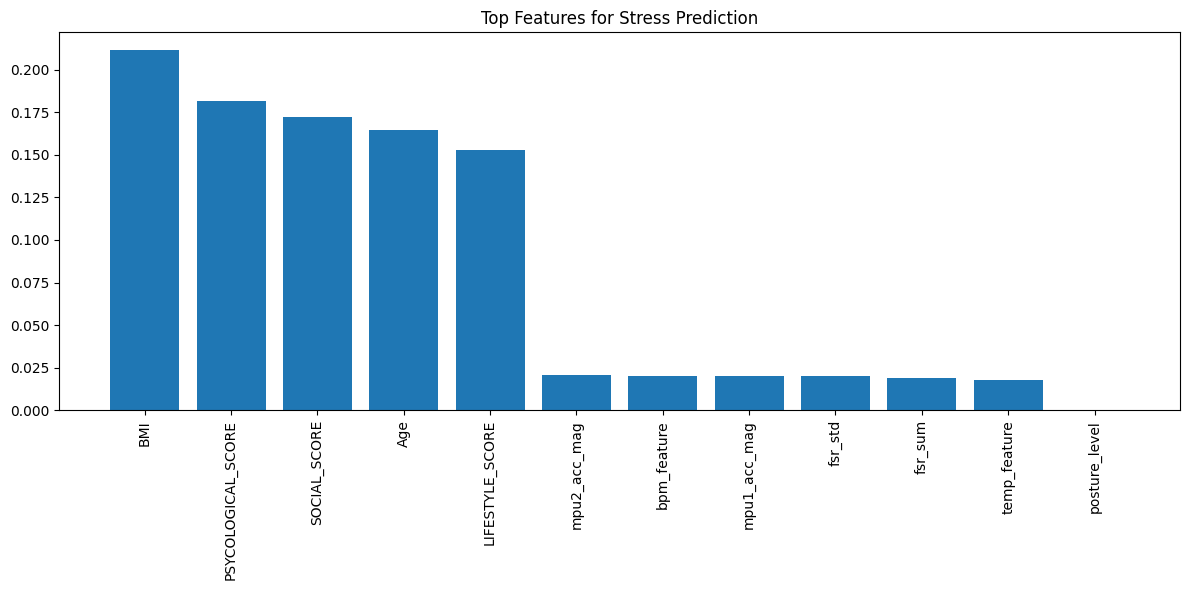

Top 10 Features:
BMI 0.21128864508456832
PSYCOLOGICAL_SCORE 0.18126097003183206
SOCIAL_SCORE 0.17221292239021468
Age 0.16443044814295368
LIFESTYLE_SCORE 0.1525792506698513
mpu2_acc_mag 0.020675082806236148
bpm_feature 0.020401361489432786
mpu1_acc_mag 0.020151944012403215
fsr_std 0.01991759505335735
fsr_sum 0.019056904808127998


In [11]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Top Features for Stress Prediction")
plt.bar(range(len(all_features)), importances[indices], align='center')
plt.xticks(range(len(all_features)), [all_features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("Top 10 Features:")
for i in range(10):
    print(all_features[indices[i]], importances[indices[i]])

##  Optional: Cross-validation

In [13]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5)
print("5-fold Cross-validation Accuracy:", cv_scores.mean())

5-fold Cross-validation Accuracy: 0.8073333333333332


In [22]:
import joblib

# Model save කරන්න (Random Forest)
joblib.dump(model, 'stress_rf_model.pkl')
print("Random Forest model saved as stress_rf_model.pkl")

Random Forest model saved as stress_rf_model.pkl


In [23]:
# Scaler save කරන්න
joblib.dump(scaler, 'stress_scaler.pkl')
print("Scaler saved as stress_scaler.pkl")

Scaler saved as stress_scaler.pkl


In [24]:
# Load scaler
scaler = joblib.load('stress_scaler.pkl')

# Load model
loaded_model = joblib.load('stress_rf_model.pkl')